### Used Car Price Analysis
##### Assignment 11.1
##### Aya Mundhenk
##### May 2026

### Overview
#### In this analysis, we will explore a dataset of used car prices to identify trends and factors that influence the pricing of used cars. We will perform data cleaning, exploratory data analysis, and build a predictive model to estimate the price of a used car based on its features.
#### Our client is a used car dealership looking to optimize their pricing strategy and better understand the market dynamics of used cars.

### Business Impact
#### By analyzing the used car price dataset, we can provide valuable insights to the dealership on how
#### The used car dealership can:
    * Price inventory competitively and accurately
    * Identify key features that drive car prices
    * Prioritize inventory based on demand and profitability
    * Advise customers on what factors affect resale value

### Import Standard Libraries

In [26]:
# Standard library imports
import warnings

# Data manipulation libraries
#!pip install numpy pandas matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn: models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Scikit-learn: model selection & evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn: models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Scikit-learn: model selection & evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)


### Load Dataset

In [27]:
# Load the dataset
df = pd.read_csv('../data/vehicles.csv')
# Display the first few rows of the dataset
print(df.head())
# Review column names and data types and non-null counts
print(df.info())
# Summary statistics for numeric columns
print(df.describe())


           id                  region  price  year manufacturer model  \
0  7222695916                prescott   6000   NaN          NaN   NaN   
1  7218891961            fayetteville  11900   NaN          NaN   NaN   
2  7221797935            florida keys  21000   NaN          NaN   NaN   
3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
4  7210384030              greensboro   4900   NaN          NaN   NaN   

  condition cylinders fuel  odometer title_status transmission  VIN drive  \
0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   

  size type paint_color state  
0  NaN  NaN         NaN    az  
1  NaN  NaN         NaN    ar  
2 

### Inspect for Missing Data

In [28]:
# Check for missing values
print(df.isnull().sum())
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('Columns with missing values:')
missing


id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64
Columns with missing values:


,Missing Count,Missing %
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24


In [29]:

pd.set_option('display.max_columns', None)
print(df)

                id                  region  price    year manufacturer  \
0       7222695916                prescott   6000     NaN          NaN   
1       7218891961            fayetteville  11900     NaN          NaN   
2       7221797935            florida keys  21000     NaN          NaN   
3       7222270760  worcester / central MA   1500     NaN          NaN   
4       7210384030              greensboro   4900     NaN          NaN   
...            ...                     ...    ...     ...          ...   
426875  7301591192                 wyoming  23590  2019.0       nissan   
426876  7301591187                 wyoming  30590  2020.0        volvo   
426877  7301591147                 wyoming  34990  2020.0     cadillac   
426878  7301591140                 wyoming  28990  2018.0        lexus   
426879  7301591129                 wyoming  30590  2019.0          bmw   

                           model condition    cylinders    fuel  odometer  \
0                            NaN  

### Data Cleaning

Rows after outlier removal: 368,719


          region manufacturer   model condition    cylinders    fuel  \
count     368719       356810  365288    228637       216967  366609   
unique       404           41   24453         6            8       5   
top     columbus         ford   f-150      good  6 cylinders     gas   
freq        3236        61030    6812    114467        84458  308087   

       title_status transmission                VIN   drive       size  \
count        362240       367217             231833  257125     102502   
unique            6            3             100432       3          4   
top           clean    automatic  1FMJU1JT1HEA52352     4wd  full-size   
freq         349934       288530                261  114913      53388   

          type paint_color   state  
count   291483      262843  368719  
unique      13          12      51  
top      sedan       white      ca  
freq     76270       69955   41402  


Text(0, 0.5, 'Frequency')

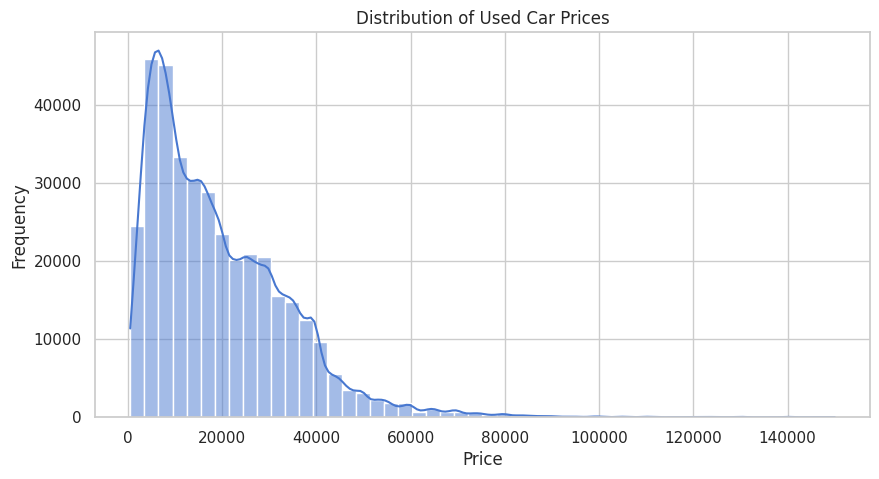

In [30]:
# Data Cleaning and Preprocessing

# Keep only realistic prices (between $500 and $150,000)
df = df[(df['price'] >= 500) & (df['price'] <= 150_000)]

# Keep only realistic odometer readings (under 500,000 miles)
df = df[(df['odometer'] >= 0) & (df['odometer'] <= 500_000)]

# Keep reasonable model years (1990 to current)
df = df[(df['year'] >= 1990) & (df['year'] <= 2024)]

print(f'Rows after outlier removal: {df.shape[0]:,}')
# Summary statistics for categorical features
print(df.describe(include=['object']))
# Distribution of the target variable (price)
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

In [31]:
# Drop columns with too many missing values (>40% missing)
df = df.drop(columns=['size', 'cylinders'])

# Drop columns that are not relevant for price prediction
df = df.drop(columns=['id'])

print(f'Remaining columns: {list(df.columns)}')

Remaining columns: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'type', 'paint_color', 'state']


In [32]:
# Drop remaining rows with null values in key features
df = df.dropna(subset=['price', 'year', 'manufacturer', 'odometer', 'transmission', 'fuel'])

print(f'Final clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Final clean dataset: 353,456 rows × 15 columns


,region,price,year,manufacturer,model,condition,fuel,odometer,title_status,transmission,VIN,drive,type,paint_color,state
27,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,gas,57923.0,clean,other,3GTP1VEC4EG551563,NaN,pickup,white,al
28,auburn,22590,2010.0,chevrolet,silverado 1500,good,gas,71229.0,clean,other,1GCSCSE06AZ123805,NaN,pickup,blue,al
29,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,gas,19160.0,clean,other,3GCPWCED5LG130317,NaN,pickup,red,al


### Exploratory Data Analysis

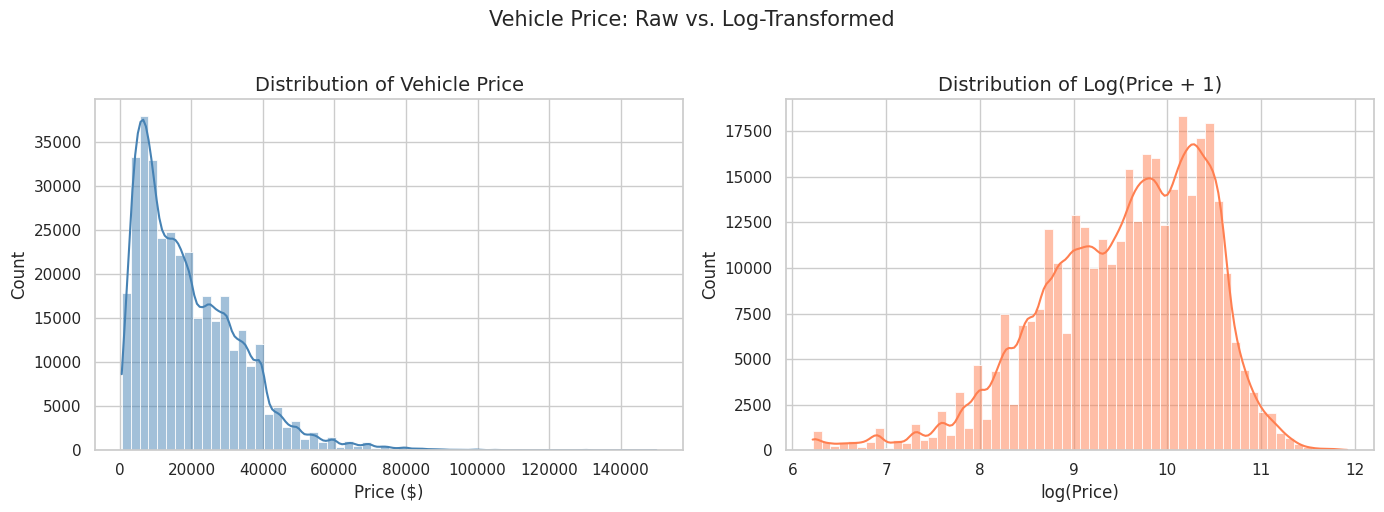

Mean price: $19,314
Median price: $15,990


In [33]:
# Price Distribution Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price distribution
sns.histplot(df['price'], bins=60, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Distribution of Vehicle Price', fontsize=14)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# Log-transformed price (reduces right skew)
sns.histplot(np.log1p(df['price']), bins=60, ax=axes[1], color='coral', kde=True)
axes[1].set_title('Distribution of Log(Price + 1)', fontsize=14)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Vehicle Price: Raw vs. Log-Transformed', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean price: ${df["price"].mean():,.0f}')
print(f'Median price: ${df["price"].median():,.0f}')

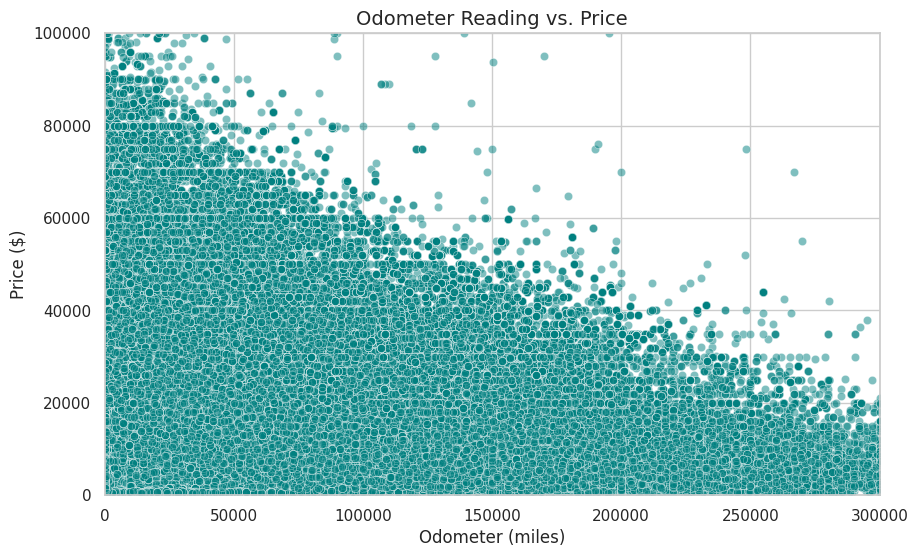

In [34]:
# Comparing Odometer vs. Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='odometer', y='price', data=df, alpha=0.5, color='teal')
plt.title('Odometer Reading vs. Price', fontsize=14)
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.xlim(0, 300_000)
plt.ylim(0, 100_000)
plt.show()

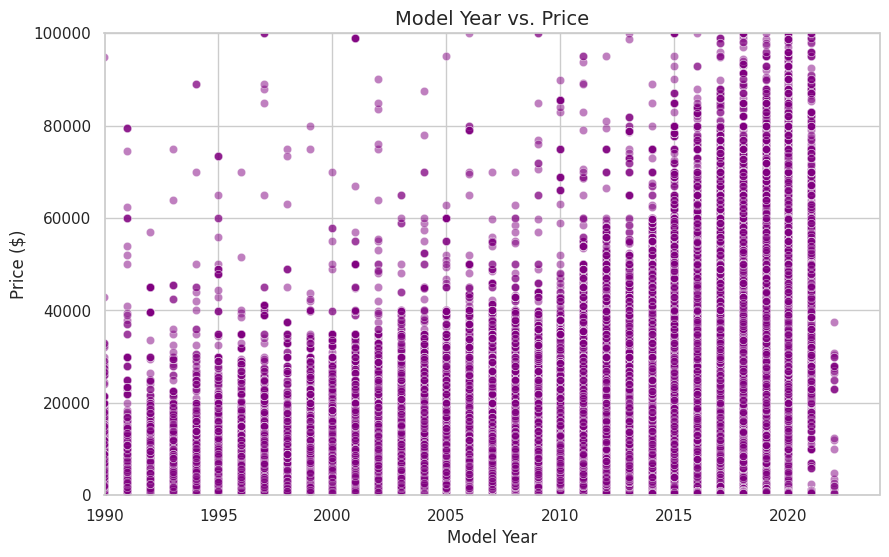

In [35]:
# Compare Year vs. Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='price', data=df, alpha=0.5, color='purple')
plt.title('Model Year vs. Price', fontsize=14)
plt.xlabel('Model Year')
plt.ylabel('Price ($)')
plt.xlim(1990, 2024)
plt.ylim(0, 100_000)
plt.show() 

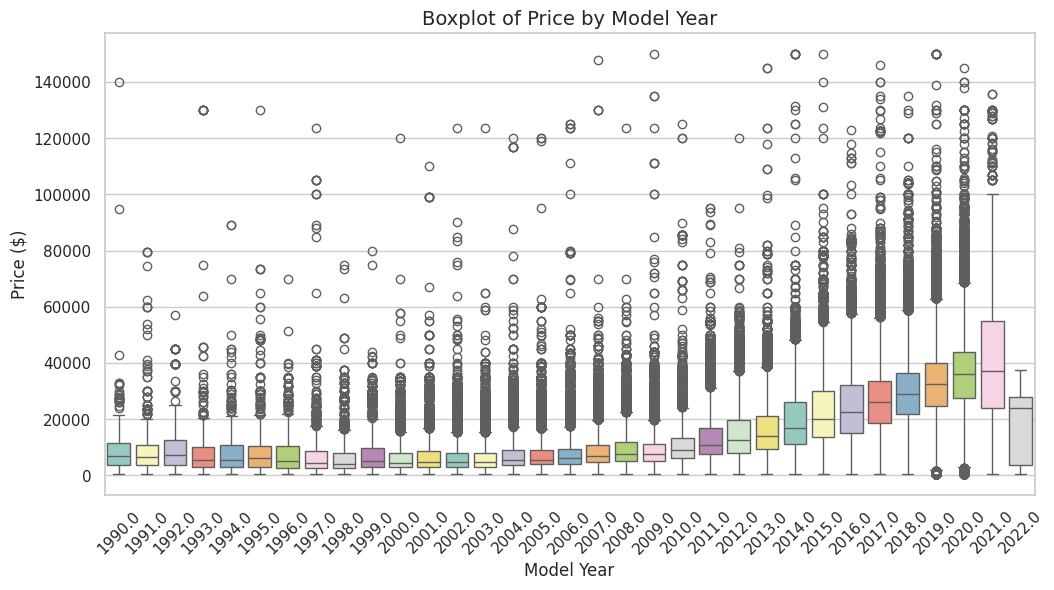

In [36]:
# Compare Year vs. Price Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='price', data=df, palette='Set3')
plt.title('Boxplot of Price by Model Year', fontsize=14)
plt.xlabel('Model Year')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.show()

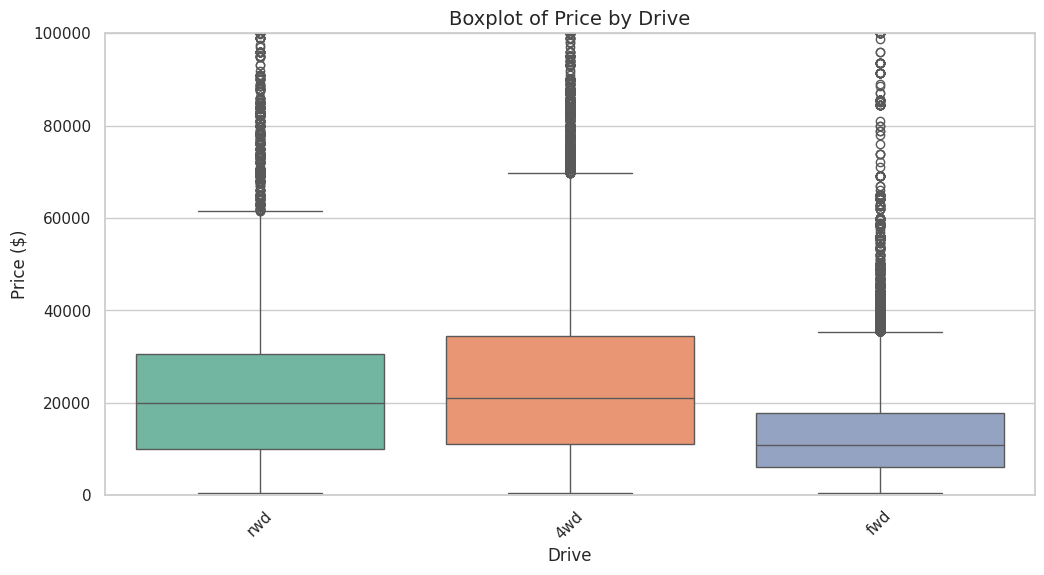

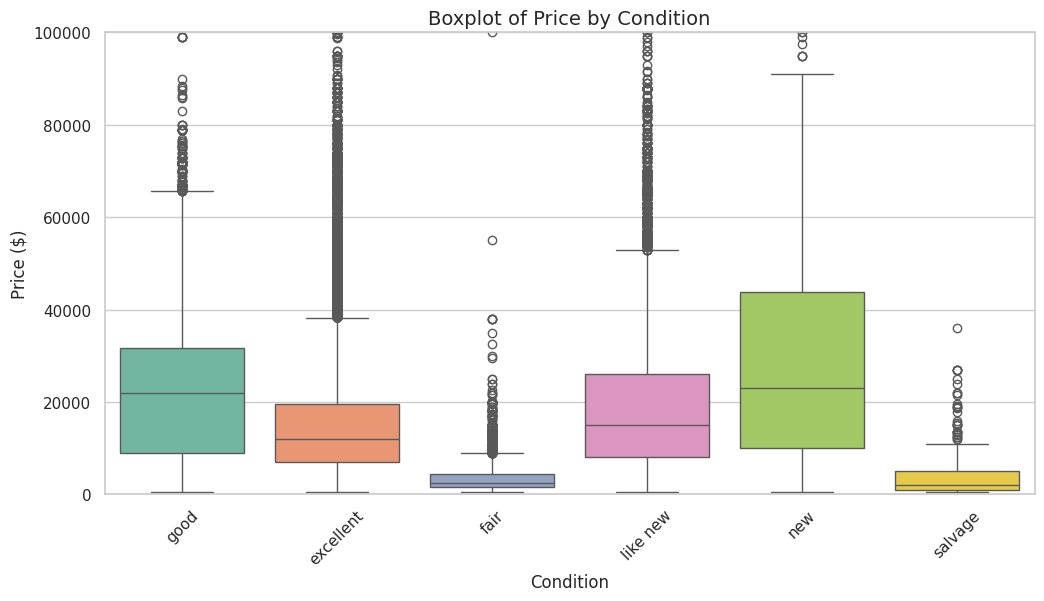

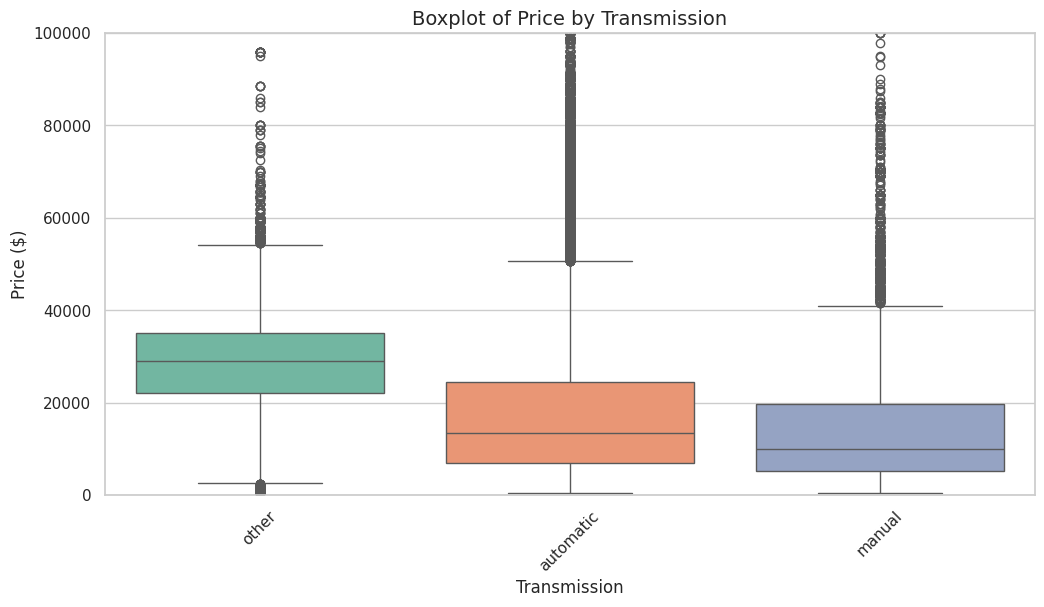

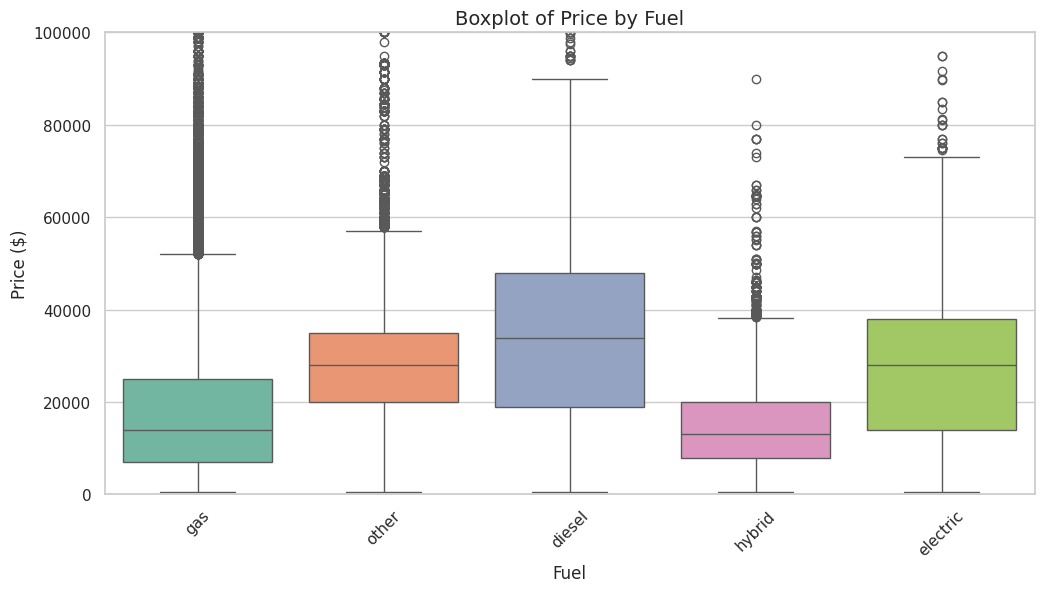

In [37]:
# Categorical Features vs. Price
categorical_features = ['drive', 'condition', 'transmission', 'fuel']
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=feature, y='price', data=df, palette='Set2')
    plt.title(f'Boxplot of Price by {feature.capitalize()}', fontsize=14)
    plt.xlabel(feature.capitalize())
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45)
    plt.ylim(0, 100_000)
    plt.show()

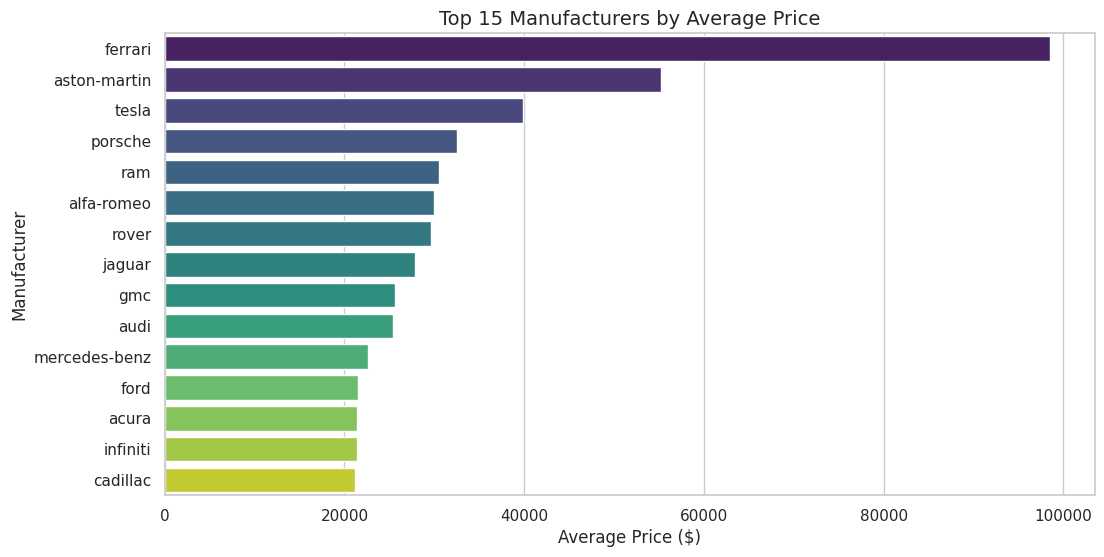

In [38]:
# Top 15 manufacturers by average price
top_manufacturers = df.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, palette='viridis')
plt.title('Top 15 Manufacturers by Average Price', fontsize=14)
plt.xlabel('Average Price ($)')
plt.ylabel('Manufacturer')  
plt.show()


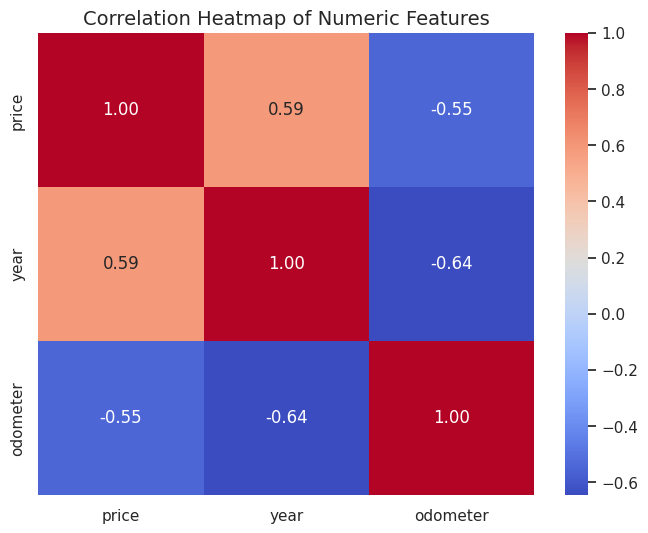

In [39]:
# Correlation Heatmap for Numeric Features
numeric_features = ['price', 'year', 'odometer']
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.show()

### Feature Engineering and Preprocessing

In [40]:
# Create vehicle age feature
df['age'] = 2024 - df['year']
plt.figure(figsize=(10, 6))

# Log-transform the target to reduce right skew
df['log_price'] = np.log1p(df['price'])

# Define feature sets
numeric_features = ['age', 'odometer']
categorical_features = ['manufacturer', 'drive', 
                        'type', 'paint_color', 'condition', 'transmission', 'fuel']

target = 'log_price'

# Drop rows still missing in selected feature columns
all_features = numeric_features + categorical_features
model_df = df[all_features + [target]].dropna().reset_index(drop=True)

print(f'Modeling dataset: {model_df.shape[0]:,} rows')
print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')


Modeling dataset: 131,784 rows
Numeric features: ['age', 'odometer']
Categorical features: ['manufacturer', 'drive', 'type', 'paint_color', 'condition', 'transmission', 'fuel']


<Figure size 1000x600 with 0 Axes>

In [41]:
# Train/test set split
X = model_df[all_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples:     {X_test.shape[0]:,}')

Training samples: 105,427
Test samples:     26,357


In [42]:
# Build Pre-Processing Pipelines
# Numerical: impute median and then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: impute most frequent and then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print('Preprocessing pipeline created.')

Preprocessing pipeline created.


### Modeling
#### Train and cross-validate on three regression models:
* Linear Regression
* Ridge Regression
* Lasso Regression

#### Evaluation Metric: RMSE
##### I will use Root Mean Squared Error as my evaluation metric.  RMSE meausre average prediction error in the same unties as the target.  RMSE is preferred over MAE becase it penalizes larger errors more heavily.  This is important when large mis-priced vehicles are costly for a dealership.

In [43]:
# Evaluate models
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    """Fit model, cross-validate, and report RMSE + R2."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # 5-fold cross-validation RMSE
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()

    print(f'{name:30s} | Test RMSE: {rmse:.4f} | R²: {r2:.4f} | CV RMSE: {cv_rmse:.4f}')
    return {'name': name, 'pipeline': pipeline, 'rmse': rmse, 'r2': r2,
            'cv_rmse': cv_rmse, 'y_pred': y_pred}

In [44]:
# Train all three baseline models
results = []

# Linear Regression
lr_pipe = Pipeline([('preprocessor', preprocessor),
                    ('model', LinearRegression())])
results.append(evaluate_model('Linear Regression', lr_pipe,
                               X_train, X_test, y_train, y_test))

# Ridge Regression
ridge_pipe = Pipeline([('preprocessor', preprocessor),
                        ('model', Ridge(alpha=1.0))])
results.append(evaluate_model('Ridge Regression (α=1)', ridge_pipe,
                               X_train, X_test, y_train, y_test))

# Lasso Regression
lasso_pipe = Pipeline([('preprocessor', preprocessor),
                        ('model', Lasso(alpha=0.01))])
results.append(evaluate_model('Lasso Regression (α=0.01)', lasso_pipe,
                               X_train, X_test, y_train, y_test))

Linear Regression              | Test RMSE: 0.4038 | R²: 0.7764 | CV RMSE: 0.4109
Ridge Regression (α=1)         | Test RMSE: 0.4039 | R²: 0.7763 | CV RMSE: 0.4109
Lasso Regression (α=0.01)      | Test RMSE: 0.4432 | R²: 0.7307 | CV RMSE: 0.4506


In [45]:
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100, 500]}

grid_search = GridSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('model', Ridge())]),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['model__alpha']
print(f'Best alpha: {best_alpha}')
print(f'Best CV RMSE: {-grid_search.best_score_:.4f}')



Best alpha: 0.01
Best CV RMSE: 0.4109


In [46]:
# Lasso hyperparameter tuning
param_grid_lasso = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

grid_search_lasso = GridSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('model', Lasso(max_iter=10000))]),
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_lasso.fit(X_train, y_train)

best_alpha_lasso = grid_search_lasso.best_params_['model__alpha']
print(f'Best Lasso alpha: {best_alpha_lasso}')
print(f'Best Lasso CV RMSE: {-grid_search_lasso.best_score_:.4f}')

best_lasso_pipe = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso_pipe.predict(X_test)
best_lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
best_lasso_r2 = r2_score(y_test, y_pred_lasso)
print(f'Tuned Lasso — Test RMSE: {best_lasso_rmse:.4f} | R²: {best_lasso_r2:.4f}')


Best Lasso alpha: 0.0001
Best Lasso CV RMSE: 0.4111
Tuned Lasso — Test RMSE: 0.4043 | R²: 0.7759


In [47]:
# Evaluate the tuned Ridge model on the test set
best_ridge_pipe = grid_search.best_estimator_
y_pred_best = best_ridge_pipe.predict(X_test)

best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2   = r2_score(y_test, y_pred_best)

print(f'Tuned Ridge — Test RMSE: {best_rmse:.4f} | R²: {best_r2:.4f}')

Tuned Ridge — Test RMSE: 0.4039 | R²: 0.7763


### Evaluation and Interpretation

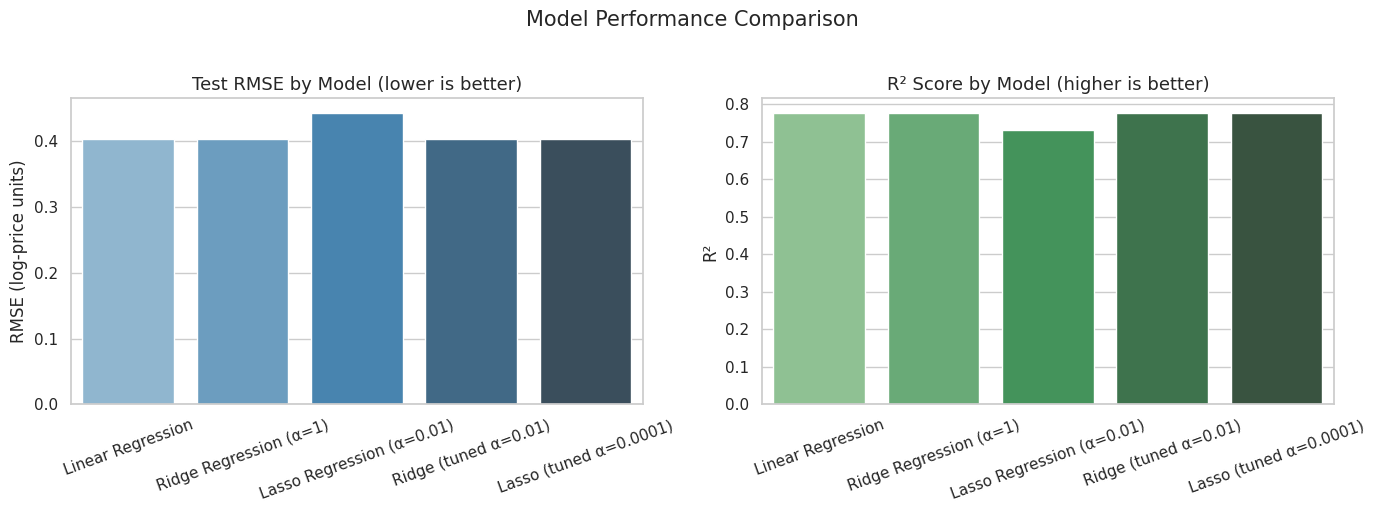

In [48]:
# Compare models - bar chart of test RMSE
model_names = [r['name'] for r in results] + [f'Ridge (tuned α={best_alpha})', f'Lasso (tuned α={best_alpha_lasso})']
rmse_vals   = [r['rmse'] for r in results] + [best_rmse, best_lasso_rmse]
r2_vals     = [r['r2']   for r in results] + [best_r2, best_lasso_r2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=model_names, y=rmse_vals, ax=axes[0], palette='Blues_d')
axes[0].set_title('Test RMSE by Model (lower is better)', fontsize=13)
axes[0].set_ylabel('RMSE (log-price units)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=model_names, y=r2_vals, ax=axes[1], palette='Greens_d')
axes[1].set_title('R² Score by Model (higher is better)', fontsize=13)
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Model Performance Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


#### Model Comparison Summary
The tuned Lasso model was included as a stronger regularization alternative to Ridge.
If its RMSE is close to Ridge, the dataset is well represented by a linear model and Ridge is preferred for stability and modest regularization.


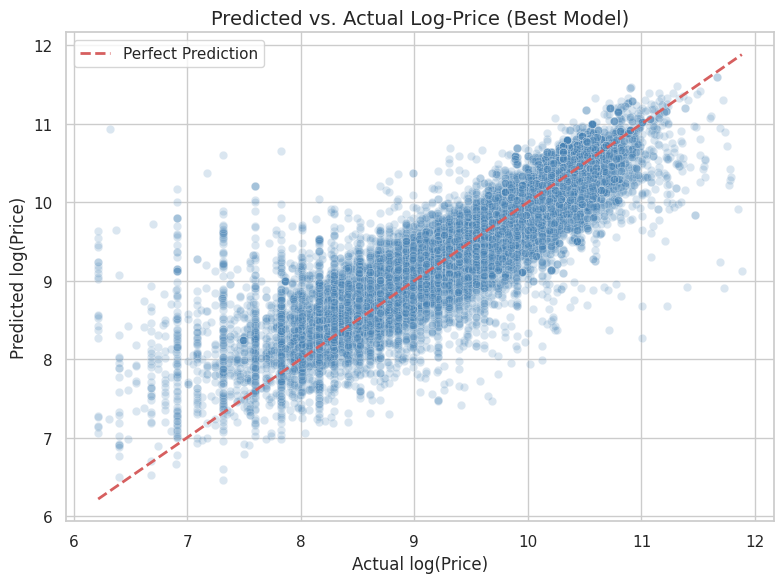

In [49]:
# Predicted vs. Actual Prices for the best model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.2, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Predicted vs. Actual Log-Price (Best Model)', fontsize=14)
plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')
plt.legend()
plt.tight_layout()
plt.show()

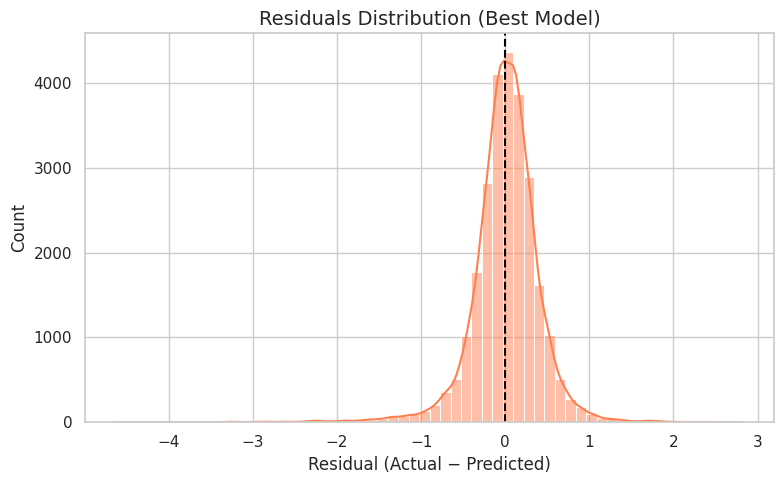

In [50]:
# Residual plot for the best model
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals Distribution (Best Model)', fontsize=14)
plt.xlabel('Residual (Actual − Predicted)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


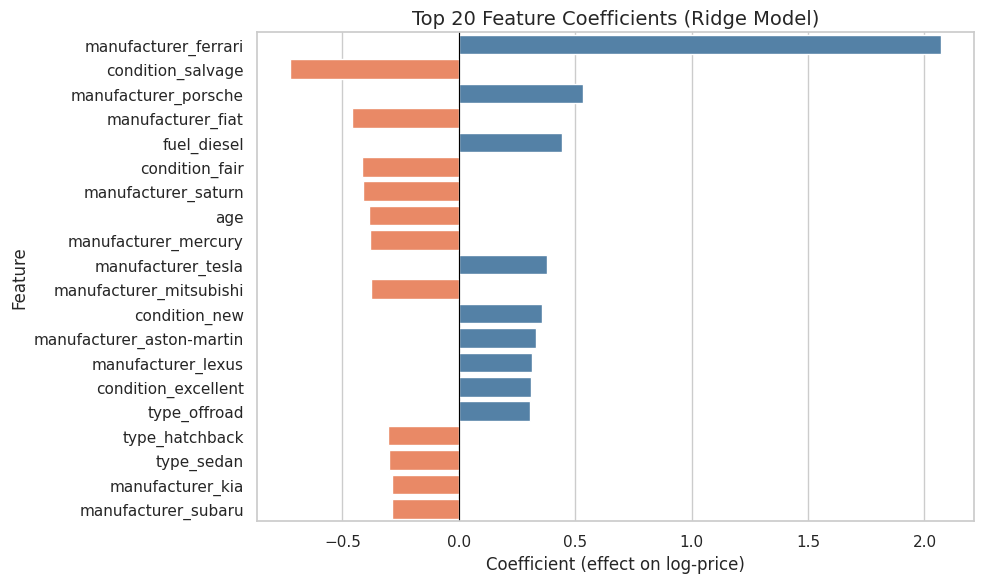


Positive coefficients → higher price | Negative → lower price
Interpretation is in log-price units (approximate % effect on price)


In [51]:
# Coefficent interpretation for the best Ridge model (numeric features only)

# Extract Ridge coefficients for numeric features
ridge_best_model = best_ridge_pipe.named_steps['model']

# Get feature names after preprocessing
ohe = best_ridge_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_names

coef_df = pd.DataFrame({'feature': all_feature_names,
                         'coefficient': ridge_best_model.coef_})

# Show top 20 features by absolute coefficient value
top_coefs = coef_df.reindex(coef_df['coefficient'].abs().nlargest(20).index)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in top_coefs['coefficient']]
sns.barplot(data=top_coefs, x='coefficient', y='feature', palette=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Feature Coefficients (Ridge Model)', fontsize=14)
plt.xlabel('Coefficient (effect on log-price)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nPositive coefficients → higher price | Negative → lower price')
print('Interpretation is in log-price units (approximate % effect on price)')

#### Findings and Recommendations
##### Key Findings
* Vehicale age and mileage are the biggest price drivers - new cards and those with few miles consistently sell for a higher price.
* Vehicle brand matters significantly - luxury and performance brands like Ferrari, Tesla, and Porsche sell for much higher prices than economy brands.
* Vehicle condition is critical - cars listed "like new" or "excellent" condition sell for much more than "fair" or "salvage" condition vehciles.  Investing in improving condition of vehicles could increase car price.
* Diesel and electric vehicles are priced higher than gas cars - customers value saving money on fuel

##### Model Performance
The final selected model was Ridge Regression with tuning, because it delivers nearly the same RMSE as Linear Regression while adding regularization to improve model stability.  Tuned Lasso was also evaluated as a more strongly regularized alternative, and both regularized models show that the dataset is well suited to linear modeling with modest regularization.

##### Recommendations for Used Car Dealerships
* Acquire newer, low-mileage vehicle inventory (clearest indicators of higher resale price)
* Invest in reconditioning vehicles (i.e. repair paint, dents/scratches, detail the car before posting pictures)
* Build a pricing tool (input parameters and outputs a good listing price)